# IMPORT LIBRARY


In [64]:
import re
import nltk
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

# READ DATA


| العمود            | الوصف                                                                                                                                 |
| ----------------- | ------------------------------------------------------------------------------------------------------------------------------------- |
| **id**            | معرف فريد لكل تعليق، مثل `0000997932d777bf`. بنستخدمه لتمييز كل تعليق عن غيره، وليس له معنى لغوي في التصنيف.                          |
| **comment_text**  | نص التعليق نفسه، وهو الـ **Input / Feature** الذي سيدخل للموديل. الموديل يحاول تحليل النص وتحديد هل يحتوي على أي نوع من السمية أم لا. |
| **toxic**         | هل التعليق **سام / مسيء بشكل عام**؟ `1` = Toxic، `0` = ليس Toxic.                                                                     |
| **severe_toxic**  | هل التعليق يحتوي على **سمية شديدة جدًا**؟ `1` = Severe Toxic، `0` = لا.                                                               |
| **obscene**       | هل التعليق يحتوي على **ألفاظ أو محتوى بذيء/فاحش**؟ `1` = Obscene، `0` = لا.                                                           |
| **threat**        | هل التعليق يحتوي على **تهديد**؟ `1` = Threat، `0` = لا.                                                                               |
| **insult**        | هل التعليق يحتوي على **إهانة أو سب** لشخص أو مجموعة؟ `1` = Insult، `0` = لا.                                                          |
| **identity_hate** | هل التعليق يحتوي على **كراهية أو إساءة موجهة لهوية/مجموعة معينة**؟ `1` = Identity Hate، `0` = لا.                                     |


In [65]:
df = pd.read_csv("train.csv")
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


# CHECK NULLS , DUBLICATE , INFO


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [67]:
print("Null values:", df.isnull().sum())
print("Duplicate values:", df.duplicated().sum())

Null values: id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64
Duplicate values: 0


In [68]:
target_columns=[
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]


# Visualization


- check class balanced


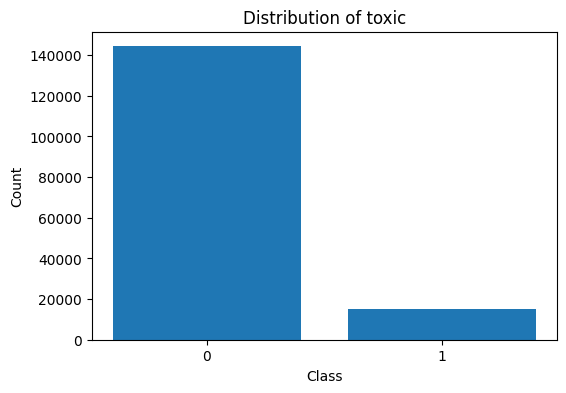

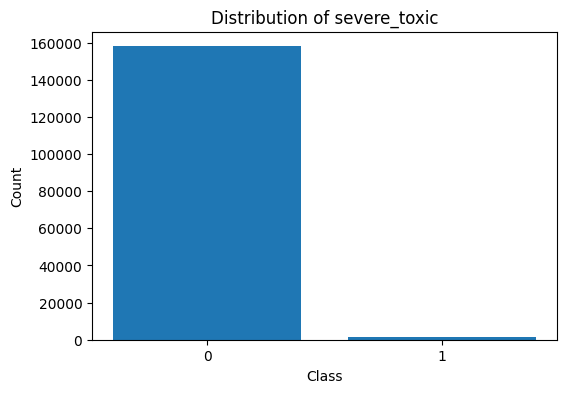

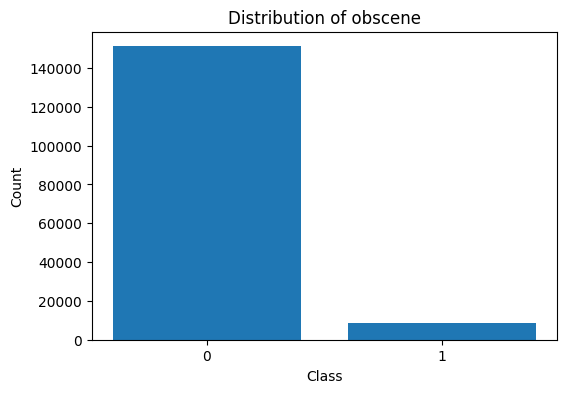

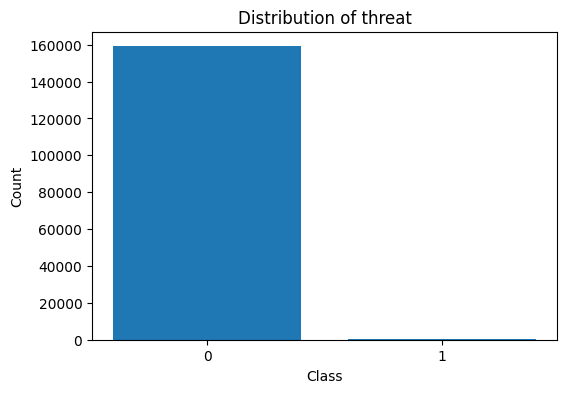

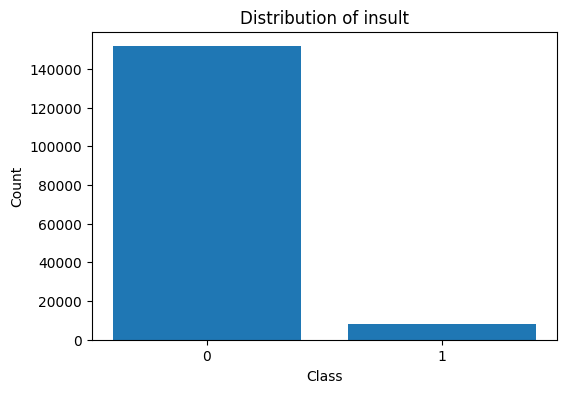

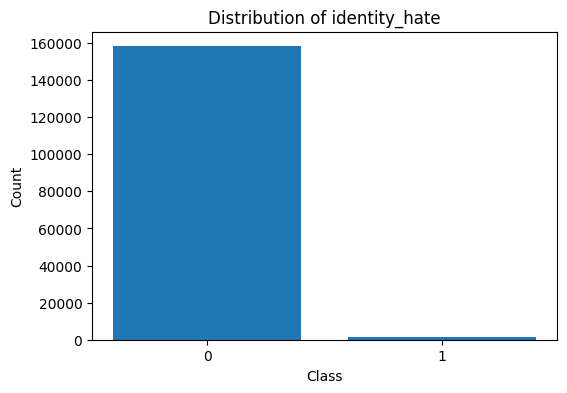

In [69]:
for col in target_columns:
    counts=df[col].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    plt.bar(counts.index,counts.values)
    plt.xticks(counts.index, counts.index)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.show()

- correlation


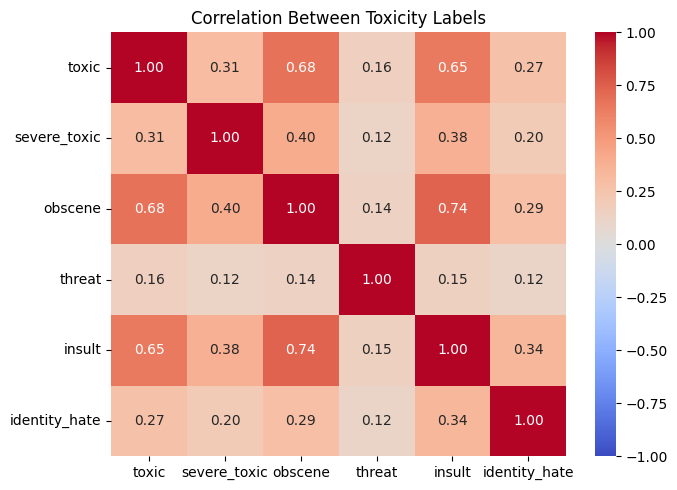

In [70]:
correlation = df[target_columns].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Toxicity Labels")
plt.tight_layout()
plt.show()

# Solve the problem of imbalanced data


In [71]:
toxic_df=df[df[target_columns].sum(axis=1)>0]
non_toxic_df=df[df[target_columns].sum(axis=1)==0]

print("Number of toxic comments:", len(toxic_df))
print("Number of non toxic comments : ",len(non_toxic_df))

Number of toxic comments: 16225
Number of non toxic comments :  143346


In [72]:
cleaned_samples=non_toxic_df.sample(n=22000, random_state=42)
balanced_data=pd.concat([toxic_df,cleaned_samples],ignore_index=True)

In [73]:
print("length of balanced data:",len(balanced_data),">>>>>>","balanced_data shape:",balanced_data.shape)
print("length of toxic data:",len(toxic_df))
print("length of non-toxic data:",len(balanced_data[balanced_data[target_columns].sum(axis=1)==0]))

length of balanced data: 38225 >>>>>> balanced_data shape: (38225, 8)
length of toxic data: 16225
length of non-toxic data: 22000


# visualize for balanced data


In [74]:
target_columns=[
    "toxic",
    "obscene",
    "insult"
    ]

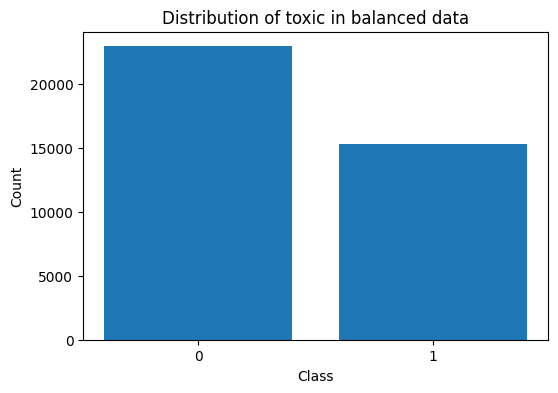

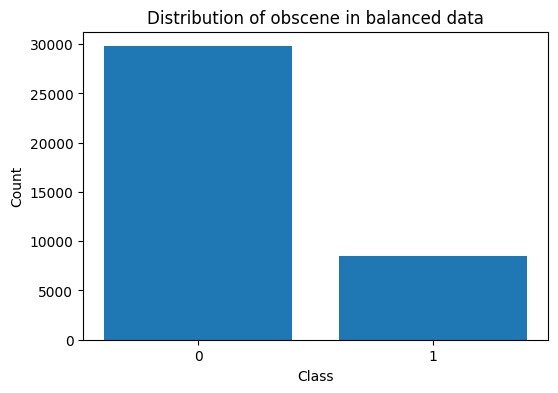

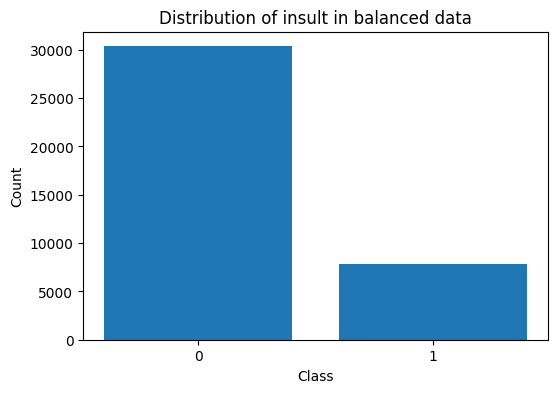

In [75]:
for col in target_columns :
    counts=balanced_data[col].value_counts().sort_index()
    plt.figure(figsize=(6,4))
    plt.bar(counts.index,counts.values)
    plt.xticks(counts.index, counts.index)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.title(f"Distribution of {col} in balanced data")
    plt.show()

# Cleaned_text


In [76]:
def cleaned_text(text:str):
    text=str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
        )
    text = re.sub(
            r"[^a-zA-Z\s]",
            " ",
            text
        )

    text = re.sub(
            r"\s+",
            " ",
            text
        )
    
    return text.strip()    

# apply clean text


In [77]:
balanced_data["cleaned_comment_text"]=balanced_data["comment_text"].apply(cleaned_text)

In [78]:
balanced_data = balanced_data[
    balanced_data["cleaned_comment_text"].str.strip().str.len() > 0
].reset_index(drop=True)
print("Dataset after removing empty comments:", balanced_data.shape)

Dataset after removing empty comments: (38222, 9)


# devide data to train , val


In [79]:
X = balanced_data["cleaned_comment_text"]

y = balanced_data[
    target_columns
].values.astype(np.float32)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [80]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)

Train: (30577,)
Validation: (7645,)


# preprocess for data


In [81]:
lemmatizer = WordNetLemmatizer()
def tokenize_data(text):

    text = cleaned_text(text)

    words = word_tokenize(text)

    words = [
        lemmatizer.lemmatize(word)
        for word in words
    ]

    return words

In [82]:
print("Tokenizing training data...")

X_train_tokens = X_train.apply(
    tokenize_data
)

X_val_tokens = X_val.apply(
    tokenize_data
)

print("Example:")
print(X_train_tokens.iloc[0])

Tokenizing training data...
Example:
['the', 'number', 'are', 'indeed', 'possible', 'first', 'is', 'that', 'the', 'number', 'from', 'the', 'election', 'can', 'not', 'be', 'used', 'to', 'compare', 'to', 'the', 'current', 'one', 'becuase', 'this', 'wa', 'before', 'the', 'point', 'in', 'which', 'the', 'youth', 'would', 'take', 'on', 'a', 'much', 'bigger', 'position', 'than', 'they', 'did', 'today', 'the', 'conservative', 'were', 'still', 'around', 'and', 'the', 'youth', 'could', 'not', 'vote', 'then', 'but', 'now', 'the', 'youth', 'can', 'vote', 'and', 'the', 'conservative', 'have', 'either', 'died', 'or', 'changed', 'to', 'rather', 'anti', 'ahmadinejad', 'the', 'conservative', 'candidate', 'wa', 'nothing', 'like', 'ahmadinejad', 'so', 'he', 'could', 'have', 'had', 'a', 'good', 'million', 'vote', 'and', 'if', 'you', 'add', 'rezaee', 'vote', 'with', 'it', 'it', 'come', 'around', 'million', 'for', 'the', 'consevatives', 'in', 'total', 'of', 'iran', 'is', 'under', 'and', 'they', 'only', 'kno

# Build Vocab


- see which is the best vocab size


In [83]:
word_counter=Counter()

for token in X_train_tokens:
    word_counter.update(token)

print("Total unique words:", len(word_counter))

Total unique words: 54588


In [84]:
for vocab_size in [5000, 10000, 20000, 30000, 50000]:
    most_common = word_counter.most_common(vocab_size)

    covered = sum(freq for word, freq in most_common)
    total = sum(word_counter.values())

    print(
        vocab_size,
        f"-> {covered / total * 100:.2f}% token coverage"
    )

5000 -> 92.63% token coverage
10000 -> 95.71% token coverage
20000 -> 97.80% token coverage
30000 -> 98.71% token coverage
50000 -> 99.76% token coverage


In [85]:
MAX_VOCAB_SIZE = 30000
vocab= {
    "<PAD>": 0,
    "<UNK>": 1
}

for word ,count in word_counter.most_common(MAX_VOCAB_SIZE-2):
    vocab[word]=len(vocab)
    
print("Vocabulary size:", len(vocab))

print("<PAD>:", vocab["<PAD>"])
print("<UNK>:", vocab["<UNK>"])

Vocabulary size: 30000
<PAD>: 0
<UNK>: 1


# Sequence length


In [86]:
length= X_train_tokens.apply(len)
print("Sequence statistic:")
print("Mean:", length.mean())
print("Median:", length.median())
print("95%:", length.quantile(0.95))
print("Max:", length.max())

Sequence statistic:
Mean: 62.31366713542859


Median: 30.0
95%: 215.0
Max: 1403


In [87]:
MAX_LENGTH = 200

# Encoding and padding


In [88]:
def encode_and_pad(tokens):
    encoded = [
        vocab.get(token, vocab["<UNK>"])
        for token in tokens
    ]
    
    if len(encoded) < MAX_LENGTH:
        encoded += [vocab["<PAD>"]] * (MAX_LENGTH - len(encoded))
    else:
        encoded = encoded[:MAX_LENGTH]
    
    return np.array(encoded, dtype=np.int64)

In [89]:
print("Encoding and padding training data...")
x_train_encoded=np.array(X_train_tokens.apply(encode_and_pad).tolist(), dtype=np.int64)
x_val_encoded=np.array(X_val_tokens.apply(encode_and_pad).tolist(), dtype=np.int64)

print("X_train:", x_train_encoded.shape)
print("X_val:", x_val_encoded.shape)

Encoding and padding training data...
X_train: (30577, 200)
X_val: (7645, 200)


# create tensors


In [90]:
x_train_tensor = torch.tensor(x_train_encoded, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
x_val_tensor = torch.tensor(x_val_encoded, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)


# create dataset


In [91]:
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)
val_dataset=TensorDataset(x_val_tensor,y_val_tensor)

# create loader


In [92]:
Batch_size=64
train_loader=DataLoader(train_dataset,batch_size=Batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=Batch_size,shuffle=False)


# Turn CUDA


In [93]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Build RNN


In [94]:
class TOXICRNN(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_dim=128,
        output_dim=3,
        dropout=0.3
    ):

        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        self.rnn = nn.RNN(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc1 = nn.Linear(
            hidden_dim * 2,
            64
        )

        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(
            64,
            output_dim
        )


    def forward(self, x):
        lengths = (x != 0).sum(dim=1)
        lengths = torch.clamp(lengths, min=1)

        lengths_cpu = lengths.cpu()

        embedded = self.embedding(x)
        packed = pack_padded_sequence(
            embedded,
            lengths_cpu,
            batch_first=True,
            enforce_sorted=False
            )
        
        _, hidden = self.rnn(packed)
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        hidden = torch.cat(
            [
                forward_hidden,
                backward_hidden
            ],
            dim=1
        )

        x = self.dropout(hidden)

        x = self.fc1(x)

        x = self.relu(x)

        x = self.dropout(x)

        x = self.fc2(x)

        return x

# Create Model


In [95]:
model = TOXICRNN(
    vocab_size=len(vocab),
    embedding_dim=128,
    hidden_dim=128,
    output_dim=3,
    dropout=0.3
).to(device)
print("model : ",model)

model :  TOXICRNN(
  (embedding): Embedding(30000, 128, padding_idx=0)
  (rnn): RNN(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=256, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


# Class weight for balance


In [96]:
positive_count=y_train.sum(axis=0)
negative_count=(len(y_train)-positive_count)

pos_weight = (
    negative_count
    / positive_count
)
print("Positive counts:",positive_count)

print("\nNegative counts:",negative_count)

print("\nPositive weights:",pos_weight)

pos_weight = torch.tensor(
    pos_weight,
    dtype=torch.float32
).to(device)

Positive counts: [12245.  6781.  6284.]

Negative counts: [18332. 23796. 24293.]

Positive weights: [1.4971008 3.509217  3.8658497]


# Loss and Optimizer


In [97]:
criterion=nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(),lr=.0005,weight_decay=1e-4)

# Training


In [98]:
EPOCHS=10
train_losses=[]

for epoch in range(EPOCHS):
    model.train()
    train_loss=0.0
    
    for xb , yb in train_loader:
        xb=xb.to(device) 
        yb=yb.to(device) 
        
        optimizer.zero_grad()
        output=model(xb)
        loss=criterion(output,yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
            )
        optimizer.step()
        train_loss += (loss.item()* xb.size(0))
        
    epoch_loss=(train_loss/len(train_dataset))
    train_losses.append(
            epoch_loss
        )
    print(
        f"Epoch {epoch + 1}/{EPOCHS} "
        f"- Train Loss: {epoch_loss:.4f}"
        )
        

Epoch 1/10 - Train Loss: 0.7489
Epoch 2/10 - Train Loss: 0.5950
Epoch 3/10 - Train Loss: 0.5238
Epoch 4/10 - Train Loss: 0.4736
Epoch 5/10 - Train Loss: 0.4422
Epoch 6/10 - Train Loss: 0.4132
Epoch 7/10 - Train Loss: 0.3939
Epoch 8/10 - Train Loss: 0.3711
Epoch 9/10 - Train Loss: 0.3528
Epoch 10/10 - Train Loss: 0.3393


# Evaluate Model


In [99]:
model.eval()

val_probs = []

val_true = []


with torch.no_grad():

    for xb, yb in val_loader:

        xb = xb.to(device)
        logits = model(xb)
        probs = torch.sigmoid(logits)

        val_probs.append(
            probs.cpu().numpy()
        )

        val_true.append(
            yb.numpy()
        )


val_probs = np.concatenate(
    val_probs,
    axis=0
)

val_true = np.concatenate(
    val_true,
    axis=0
)



- select bast threeshold


In [100]:
thresholds = np.arange(
    0.10,
    0.91,
    0.05
)

best_thresholds = []

print("Best Thresholds:\n")

for i, label in enumerate(
    target_columns
):

    best_threshold = 0.5
    best_f1 = 0.0
    
    for threshold in thresholds:
        preds = (
            val_probs[:, i]
            >= threshold
        ).astype(int)


        score = f1_score(
            val_true[:, i],
            preds,
            zero_division=0
        )
        if score > best_f1:

            best_f1 = score
            best_threshold = threshold

    best_thresholds.append(
        best_threshold
    )


    print(
        f"{label}: "
        f"Threshold = {best_threshold:.2f} "
        f"| F1 = {best_f1:.4f}"
    )


best_thresholds = np.array(
    best_thresholds
)

Best Thresholds:

toxic: Threshold = 0.45 | F1 = 0.8600
obscene: Threshold = 0.70 | F1 = 0.7904
insult: Threshold = 0.55 | F1 = 0.7134


# Val prediction


In [101]:
y_pred = (
    val_probs
    >= best_thresholds
).astype(int)

In [102]:
print("Classification Report:\n")

print(
    classification_report(
        val_true,
        y_pred,
        target_names=target_columns,
        zero_division=0
    )
)


avg_f1 = f1_score(
    val_true,
    y_pred,
    average="macro",
    zero_division=0
)

avg_precision = precision_score(
    val_true,
    y_pred,
    average="macro",
    zero_division=0
)

avg_recall = recall_score(
    val_true,
    y_pred,
    average="macro",
    zero_division=0
)


print(
    f"Macro F1        : {avg_f1:.4f}"
)

print(
    f"Macro Precision  : {avg_precision:.4f}"
)

print(
    f"Macro Recall     : {avg_recall:.4f}"
)

Classification Report:

              precision    recall  f1-score   support

       toxic       0.86      0.86      0.86      3049
     obscene       0.79      0.80      0.79      1668
      insult       0.63      0.82      0.71      1593

   micro avg       0.77      0.83      0.80      6310
   macro avg       0.76      0.82      0.79      6310
weighted avg       0.78      0.83      0.80      6310
 samples avg       0.30      0.33      0.30      6310

Macro F1        : 0.7879
Macro Precision  : 0.7588
Macro Recall     : 0.8249


In [103]:
from sklearn.metrics import accuracy_score
print("Classification Report:\n")

print(
    classification_report(
        val_true,
        y_pred,
        target_names=target_columns,
        zero_division=0
    )
)

accuracy = accuracy_score(
    val_true,
    y_pred
)

avg_f1 = f1_score(
    val_true,
    y_pred,
    average="macro",
    zero_division=0
)

avg_precision = precision_score(
    val_true,
    y_pred,
    average="macro",
    zero_division=0
)

avg_recall = recall_score(
    val_true,
    y_pred,
    average="macro",
    zero_division=0
)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro F1        : {avg_f1:.4f}")
print(f"Macro Precision : {avg_precision:.4f}")
print(f"Macro Recall    : {avg_recall:.4f}")


print("\nAccuracy per class:")

for i, label in enumerate(target_columns):

    acc = accuracy_score(
        val_true[:, i],
        y_pred[:, i]
    )

    print(f"{label:10s}: {acc:.4f}")

Classification Report:

              precision    recall  f1-score   support

       toxic       0.86      0.86      0.86      3049
     obscene       0.79      0.80      0.79      1668
      insult       0.63      0.82      0.71      1593

   micro avg       0.77      0.83      0.80      6310
   macro avg       0.76      0.82      0.79      6310
weighted avg       0.78      0.83      0.80      6310
 samples avg       0.30      0.33      0.30      6310

Accuracy        : 0.7383
Macro F1        : 0.7879
Macro Precision : 0.7588
Macro Recall    : 0.8249

Accuracy per class:
toxic     : 0.8882
obscene   : 0.9079
insult    : 0.8630


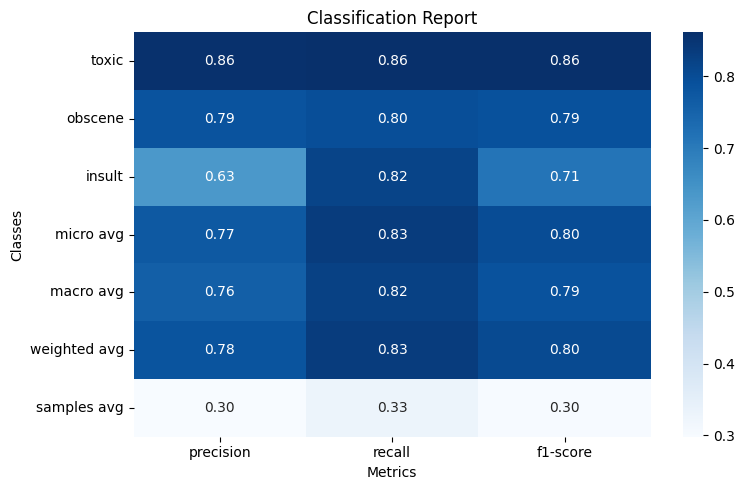

In [104]:
report = classification_report(
    val_true,
    y_pred,
    target_names=target_columns,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).T

plt.figure(figsize=(8, 5))

sns.heatmap(
    report_df.iloc[:, :3],
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Classification Report")
plt.xlabel("Metrics")
plt.ylabel("Classes")

plt.tight_layout()
plt.show()

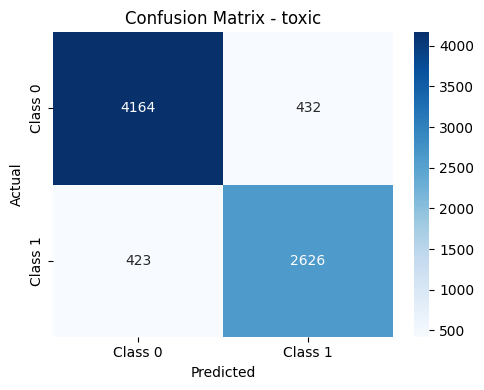

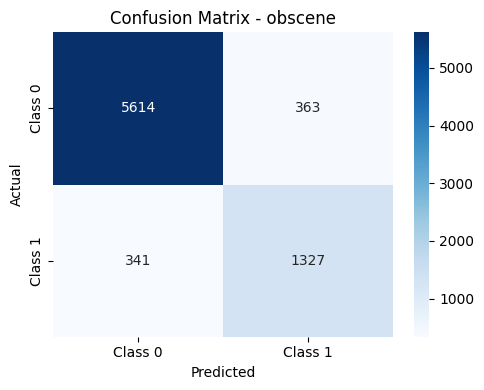

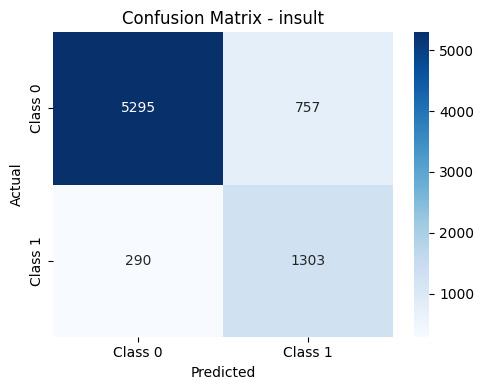

In [105]:
for i, label in enumerate(target_columns):

    cm = confusion_matrix(
        val_true[:, i],
        y_pred[:, i]
    )

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"]
    )

    plt.title(f"Confusion Matrix - {label}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

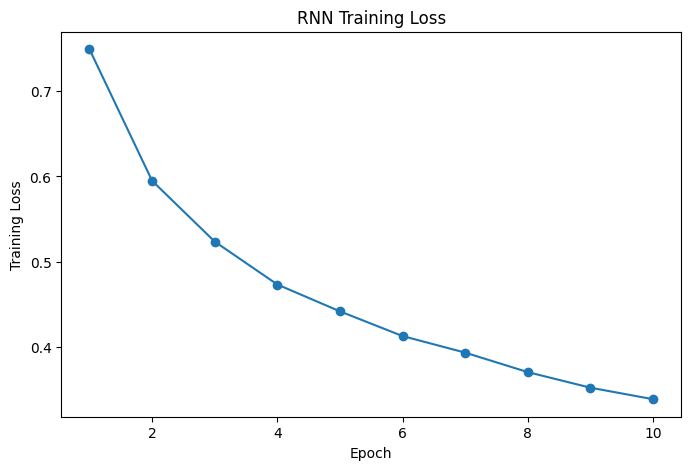

In [106]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, EPOCHS + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Training Loss")

plt.title("RNN Training Loss")

plt.show()

# Save Model


In [107]:
best_thresholds = np.array(best_thresholds)


In [108]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "thresholds": best_thresholds,
    "vocab": vocab,
    "target_columns": target_columns,
    "embedding_dim": 128,
    "hidden_dim": 128,
    "dropout": 0.3,
    "max_len": MAX_LENGTH
}

torch.save(
    checkpoint,
    "toxic_rnn_checkpoint.pth"
)

print("Checkpoint saved successfully!")

Checkpoint saved successfully!


# Use final data for training in all training data set


In [109]:
X_train = balanced_data["cleaned_comment_text"]
y_train = balanced_data[target_columns].values.astype(np.float32)

In [110]:
print("Tokenizing training data...")

X_train_tokens = X_train.apply(
    tokenize_data
)

Tokenizing training data...


In [111]:
word_counter=Counter()

for token in X_train_tokens:
    word_counter.update(token)

print("Total unique words:", len(word_counter))

Total unique words: 61842


In [112]:
MAX_VOCAB_SIZE = 30000
vocab= {
    "<PAD>": 0,
    "<UNK>": 1
}

for word ,count in word_counter.most_common(MAX_VOCAB_SIZE-2):
    vocab[word]=len(vocab)
    
print("Vocabulary size:", len(vocab))

print("<PAD>:", vocab["<PAD>"])
print("<UNK>:", vocab["<UNK>"])

Vocabulary size: 30000
<PAD>: 0
<UNK>: 1


In [113]:
print("Encoding and padding training data...")
x_train_encoded=np.array(X_train_tokens.apply(encode_and_pad).tolist(), dtype=np.int64)

Encoding and padding training data...


In [114]:
x_train_tensor = torch.tensor(x_train_encoded, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

In [115]:
train_dataset=TensorDataset(x_train_tensor,y_train_tensor)


In [116]:
Batch_size=64
train_loader=DataLoader(train_dataset,batch_size=Batch_size,shuffle=True)

In [117]:
EPOCHS = 10

train_losses = []
train_accuracies = []
train_f1s = []
train_precisions = []
train_recalls = []

for epoch in range(EPOCHS):

    model.train()

    train_loss = 0.0

    all_train_preds = []
    all_train_labels = []

    for xb, yb in train_loader:

        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        output = model(xb)

        loss = criterion(output, yb)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        train_loss += loss.item() * xb.size(0)

        probs = torch.sigmoid(output)

        preds = (probs >= best_threshold).float()

        all_train_preds.append(
            preds.detach().cpu().numpy()
        )

        all_train_labels.append(
            yb.detach().cpu().numpy()
        )


    epoch_loss = train_loss / len(train_dataset)

    train_preds = np.vstack(all_train_preds)
    train_labels = np.vstack(all_train_labels)


    train_accuracy = accuracy_score(
        train_labels,
        train_preds
    )

    train_f1 = f1_score(
        train_labels,
        train_preds,
        average="macro",
        zero_division=0
    )

    train_precision = precision_score(
        train_labels,
        train_preds,
        average="macro",
        zero_division=0
    )

    train_recall = recall_score(
        train_labels,
        train_preds,
        average="macro",
        zero_division=0
    )

    train_losses.append(epoch_loss)
    train_accuracies.append(train_accuracy)
    train_f1s.append(train_f1)
    train_precisions.append(train_precision)
    train_recalls.append(train_recall)


    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {train_accuracy:.4f} | "
        f"F1: {train_f1:.4f} | "
        f"Precision: {train_precision:.4f} | "
        f"Recall: {train_recall:.4f}"
    )

Epoch 1/10 | Loss: 0.6375 | Accuracy: 0.6414 | F1: 0.6763 | Precision: 0.6125 | Recall: 0.7679
Epoch 2/10 | Loss: 0.4403 | Accuracy: 0.7229 | F1: 0.7749 | Precision: 0.7092 | Recall: 0.8695
Epoch 3/10 | Loss: 0.3956 | Accuracy: 0.7384 | F1: 0.7950 | Precision: 0.7242 | Recall: 0.8960
Epoch 4/10 | Loss: 0.3672 | Accuracy: 0.7505 | F1: 0.8065 | Precision: 0.7336 | Recall: 0.9100
Epoch 5/10 | Loss: 0.3514 | Accuracy: 0.7552 | F1: 0.8118 | Precision: 0.7374 | Recall: 0.9161
Epoch 6/10 | Loss: 0.3407 | Accuracy: 0.7607 | F1: 0.8169 | Precision: 0.7418 | Recall: 0.9211
Epoch 7/10 | Loss: 0.3328 | Accuracy: 0.7661 | F1: 0.8227 | Precision: 0.7485 | Recall: 0.9248
Epoch 8/10 | Loss: 0.3261 | Accuracy: 0.7680 | F1: 0.8247 | Precision: 0.7495 | Recall: 0.9280
Epoch 9/10 | Loss: 0.3151 | Accuracy: 0.7740 | F1: 0.8293 | Precision: 0.7555 | Recall: 0.9292
Epoch 10/10 | Loss: 0.3107 | Accuracy: 0.7778 | F1: 0.8333 | Precision: 0.7585 | Recall: 0.9339


In [118]:
from sklearn.metrics import accuracy_score
print("Classification Report:\n")

print(
    classification_report(
        train_labels,
        train_preds,
        target_names=target_columns,
        zero_division=0
    )
)

accuracy = accuracy_score(
    train_labels,
    train_preds
)

avg_f1 = f1_score(
    train_labels,
    train_preds,
    average="macro",
    zero_division=0
)

avg_precision = precision_score(
    train_labels,
    train_preds,
    average="macro",
    zero_division=0
)

avg_recall = recall_score(
    train_labels,
    train_preds,
    average="macro",
    zero_division=0
)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro F1        : {avg_f1:.4f}")
print(f"Macro Precision : {avg_precision:.4f}")
print(f"Macro Recall    : {avg_recall:.4f}")


print("\nAccuracy per class:")

for i, label in enumerate(target_columns):

    acc = accuracy_score(
        train_labels[:, i],
        train_preds[:, i]
    )

    print(f"{label:10s}: {acc:.4f}")

Classification Report:

              precision    recall  f1-score   support

       toxic       0.88      0.92      0.90     15294
     obscene       0.76      0.94      0.84      8449
      insult       0.64      0.94      0.76      7877

   micro avg       0.77      0.93      0.84     31620
   macro avg       0.76      0.93      0.83     31620
weighted avg       0.79      0.93      0.85     31620
 samples avg       0.32      0.38      0.34     31620

Accuracy        : 0.7778
Macro F1        : 0.8333
Macro Precision : 0.7585
Macro Recall    : 0.9339

Accuracy per class:
toxic     : 0.9181
obscene   : 0.9219
insult    : 0.8764


# TEST DATA AND CREATE A FILE FOR SUMMITION


In [119]:
test_df = pd.read_csv("test.csv")
test_df.info()
test_df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153164 entries, 0 to 153163
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            153164 non-null  object
 1   comment_text  153164 non-null  object
dtypes: object(2)
memory usage: 2.3+ MB


np.int64(0)

In [120]:
X_test = test_df["comment_text"]

test_df["clean_text"] = X_test.apply(cleaned_text)
X_test_clean=test_df["clean_text"]

X_test_tokens = X_test_clean.apply(tokenize_data)

X_test_encoded = X_test_tokens.apply(
    encode_and_pad
).tolist()

X_test_tensor = torch.tensor(
    X_test_encoded,
    dtype=torch.long
)

test_dataset = TensorDataset(
    X_test_tensor
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [121]:
model.eval()

test_predictions = []

with torch.no_grad():

    for batch in test_loader:

        xb = batch[0].to(device)

        logits = model(xb)

        probs = torch.sigmoid(logits)

        preds = (
            probs.cpu().numpy()
            >= best_thresholds
        ).astype(float)

        test_predictions.append(
            preds
        )

test_predictions = np.vstack(
    test_predictions
)

In [122]:
predictions_df = pd.DataFrame(
    test_predictions,
    columns=target_columns
)

predictions_df.insert(
    0,
    "clean_text",
    test_df["clean_text"].values
)

predictions_df.to_csv(
    "test_predictions_rnn_2.csv",
    index=False
)

print(predictions_df.head())

                                          clean_text  toxic  obscene  insult
0  yo bitch ja rule is more succesful then you ll...    1.0      1.0     1.0
1            from rfc the title is fine as it is imo    0.0      0.0     0.0
2                     sources zawe ashton on lapland    0.0      0.0     0.0
3  if you have a look back at the source the info...    0.0      0.0     0.0
4           i don t anonymously edit articles at all    0.0      0.0     0.0


In [123]:
print(predictions_df.head(30))

                                           clean_text  toxic  obscene  insult
0   yo bitch ja rule is more succesful then you ll...    1.0      1.0     1.0
1             from rfc the title is fine as it is imo    0.0      0.0     0.0
2                      sources zawe ashton on lapland    0.0      0.0     0.0
3   if you have a look back at the source the info...    0.0      0.0     0.0
4            i don t anonymously edit articles at all    0.0      0.0     0.0
5   thank you for understanding i think very highl...    0.0      0.0     0.0
6   please do not add nonsense to wikipedia such e...    0.0      0.0     0.0
7                      dear god this site is horrible    1.0      0.0     0.0
8   only a fool can believe in such numbers the co...    0.0      0.0     0.0
9   double redirects when fixing double redirects ...    0.0      0.0     0.0
10  i think its crap that the link to roggenbier i...    1.0      0.0     0.0
11  somebody will invariably try to add religion r...    0.0    

# TEST WITH PROPAPILYTY FOR EACH CLASS


In [124]:
model.eval()

test_probabilities = []

with torch.no_grad():

    for batch in test_loader:

        xb = batch[0].to(device)

        logits = model(xb)

        probs = torch.sigmoid(logits)

        test_probabilities.append(
            probs.cpu().numpy()
        )

test_probabilities = np.vstack(
    test_probabilities
)

In [125]:
predictions_df_2 = pd.DataFrame(
    test_probabilities,
    columns=target_columns
)

predictions_df_2.insert(
    0,
    "comment_text",
    test_df["comment_text"].values
)

predictions_df_2.to_csv(
    "test_probabilities_rnn_2.csv",
    index=False
)

print(predictions_df_2.head(10))

                                        comment_text     toxic   obscene  \
0  Yo bitch Ja Rule is more succesful then you'll...  0.993768  0.971422   
1  == From RfC == \n\n The title is fine as it is...  0.003093  0.000043   
2  " \n\n == Sources == \n\n * Zawe Ashton on Lap...  0.029036  0.006537   
3  :If you have a look back at the source, the in...  0.030690  0.003265   
4          I don't anonymously edit articles at all.  0.026142  0.000148   
5  Thank you for understanding. I think very high...  0.014528  0.000809   
6  Please do not add nonsense to Wikipedia. Such ...  0.032376  0.003479   
7                   :Dear god this site is horrible.  0.817606  0.085657   
8  " \n Only a fool can believe in such numbers. ...  0.212835  0.060325   
9  == Double Redirects == \n\n When fixing double...  0.001998  0.000095   

     insult  
0  0.884036  
1  0.000025  
2  0.002270  
3  0.000449  
4  0.000118  
5  0.000766  
6  0.001461  
7  0.245740  
8  0.020809  
9  0.000014  
